In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

In [8]:
import pandas as pd

df = pd.read_csv("../data/online_retail_customer_churn.csv")

In [11]:
import numpy as np

df_numeric = df.select_dtypes(include=[np.number]).dropna()

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)


In [15]:
from sklearn.cluster import KMeans

optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_numeric['Cluster'] = clusters


Feature Importance for Clusters:
                   Feature  Importance
4     customer_value_score    0.248439
6             monetary_log    0.185393
2                 monetary    0.177976
3   avg_spend_per_purchase    0.163710
1                frequency    0.135763
5  recency_frequency_ratio    0.071864
0                  recency    0.016855


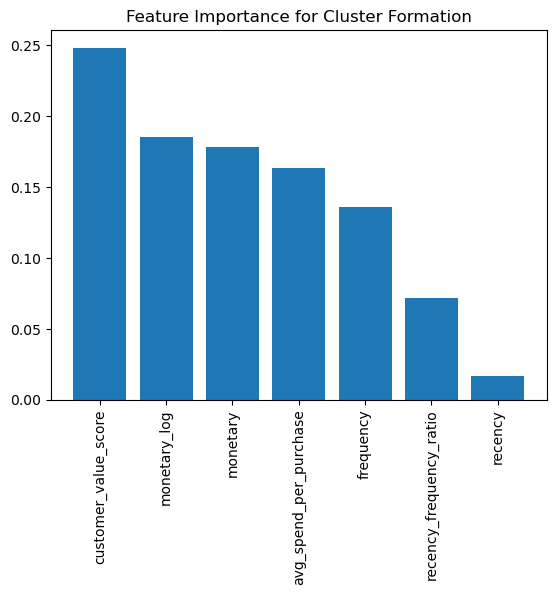

In [23]:

# 5. Feature Importance using Random Forest

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
X = df_numeric.drop('Cluster', axis=1)
y = df_numeric['Cluster']

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance for Clusters:")
print(feature_importance)

# Plot Feature Importance
plt.figure()
plt.bar(feature_importance['Feature'], feature_importance['Importance'])
plt.xticks(rotation=90)
plt.title("Feature Importance for Cluster Formation")
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt


# 6. Identify Spending & Frequency Columns


spend_col = None
freq_col = None

for col in df.columns:
    if 'spend' in col.lower() or 'amount' in col.lower():
        spend_col = col
    if 'frequency' in col.lower() or 'transaction' in col.lower():
        freq_col = col

print("Detected Spending Column:", spend_col)
print("Detected Frequency Column:", freq_col)


Detected Spending Column: avg_spend_per_purchase
Detected Frequency Column: recency_frequency_ratio


In [22]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt


# 7. Calculate CLV


if spend_col and freq_col:
    df['CLV'] = df[spend_col] * df[freq_col]
else:
    # fallback: use total numeric mean if exact columns missing
    df['CLV'] = df_numeric.mean(axis=1)

print("\nCLV Sample:")
print(df[['CLV']].head())



CLV Sample:
         CLV
0  55.695463
1  19.285192
2   1.551850
3  23.642647
4  41.768182


In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# 8. CLV Segmentation


df['CLV_Group'] = pd.qcut(df['CLV'], 
                           q=3, 
                           labels=['Low Value', 'Medium Value', 'High Value'])

print("\nCLV Distribution:")
print(df['CLV_Group'].value_counts())

# CLV Summary
print("\nCLV Statistics:")
print(df.groupby('CLV_Group')['CLV'].mean())




CLV Distribution:
CLV_Group
Low Value       263
Medium Value    263
High Value      263
Name: count, dtype: int64

CLV Statistics:
CLV_Group
Low Value        3.154426
Medium Value    13.265465
High Value      54.871464
Name: CLV, dtype: float64


C:\Users\Admin\AppData\Local\Temp\ipykernel_7248\2315433056.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('CLV_Group')['CLV'].mean())
